In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
%matplotlib inline

In [3]:
df = pd.read_csv("../data/cleaned_songs.csv")

In [4]:
df.shape
df.head()

,name,album,artist,id,release_date,popularity,length,danceability,acousticness,energy,instrumentalness,liveness,valence,loudness,speechiness,tempo,key,time_signature,mood
0,1999,1999,Prince,2H7PHVdQ3mXqEHXcvclTB0,1982-10-27,68,379266,0.866,0.13700,0.730,0.000000,0.0843,0.625,-8.201,0.0767,118.523,5,4,Happy
1,23,23,Blonde Redhead,4HIwL9ii9CcXpTOTzMq0MP,2007-04-16,43,318800,0.381,0.01890,0.832,0.196000,0.1530,0.166,-5.069,0.0492,120.255,8,4,Sad
2,9 Crimes,9,Damien Rice,5GZEeowhvSieFDiR8fQ2im,2006-11-06,60,217946,0.346,0.91300,0.139,0.000077,0.0934,0.116,-15.326,0.0321,136.168,0,4,Sad
3,99 Luftballons,99 Luftballons,Nena,6HA97v4wEGQ5TUClRM0XLc,1984-08-21,2,233000,0.466,0.08900,0.438,0.000006,0.1130,0.587,-12.858,0.0608,193.100,4,4,Happy
4,A Boy Brushed Red Living In Black And White,They're Only Chasing Safety,Underoath,47IWLfIKOKhFnz1FUEUIkE,2004-01-01,60,268000,0.419,0.00171,0.932,0.000000,0.1370,0.445,-3.604,0.1060,169.881,1,4,Energetic


In [5]:
#selecting the features + scaling them

features = [
    "danceability", "energy", "valence", "tempo", "acousticness",
    "instrumentalness", "speechiness"]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaling shape:", X_scaled.shape)

Scaling shape: (686, 7)


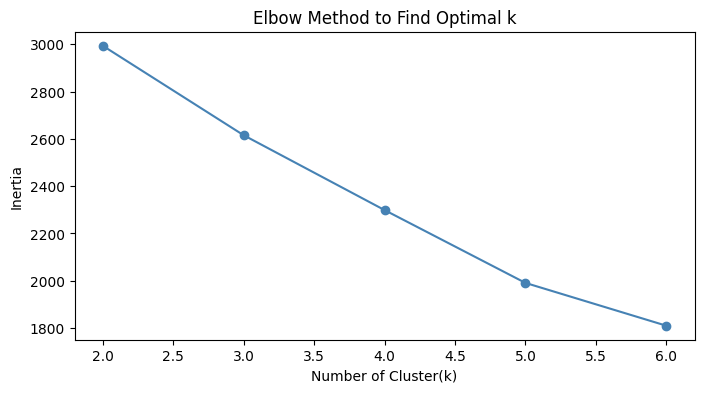

In [6]:
#Elbow method
inertia = []
k_range = range(2, 7)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init = 10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.xlabel("Number of Cluster(k)")
plt.ylabel("Inertia")
plt.title("Elbow Method to Find Optimal k")
plt.savefig("../plots/elbow_plot.png", dpi=150)
plt.show()

For the elbow method visualization above, I was expected a sharp bend shape of the line for this graph. However, after running the code from above with the random state of 42 and initialized it to 10 to make the cluster producing reproducible. And through the line plot above, it is showing a gradual decreasing pattern which doesn't show me a clear answer of what my k value should be. Through the elbow method, if there was a sharp bend at one singular point, it would clearly tell what k value is optimal. But since this method didn't show me a definitive answer, I concluded that I would need to use another method to find the optimal k value. 

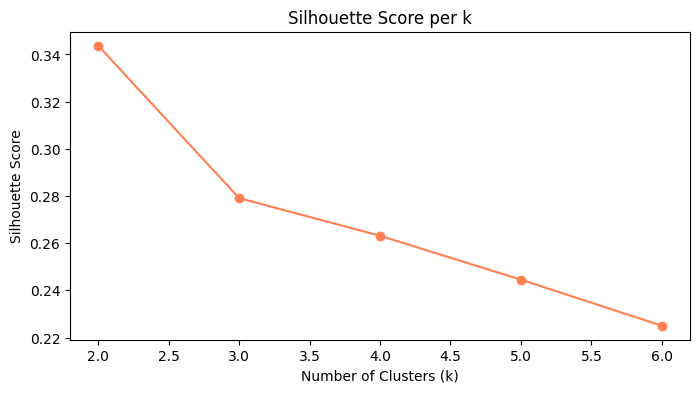

In [7]:
#silhouette score per k
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8,4))
plt.plot(k_range, silhouette_scores, marker='o', color='coral')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score per k")
plt.savefig("../plots/silhouette_per_k.png", dpi=150)
plt.show()

    

Since the Elbow method didn't give me sufficient information on what value of K I should use for the clustering, I decided to explore the Silhouette Score method since this one mathematically decides through using its range from -1 to 1. So basically if the silhouette number is closer to 1, then that means that the songs are farther away from other clusters and will have perfect grouping among the members of its own cluster group which is good. However, if the number is closer to 0 then that means it is overlapping and their is no clear clusters separating between the songs. Thus from the line plot above, I can tell that with a silhouette score of 0.34, it recommends k=2. And since k=2 is not enough number of clusters to come up with meaningful analysis, I decided to make a judgement call to finally choose k=4.

In [8]:
#deciding whether to include loudness in features or not
#as it is very similar to energy and wouldn't want the KMeans clustering
#model to count for it twice - need to be more effective

features_no_loudness = [
    "danceability", "energy", "valence", "tempo", "acousticness", 
    "instrumentalness", "speechiness"
]

features_with_loudness = [
    "danceability", "energy", "valence", "tempo", "acousticness", 
    "instrumentalness", "speechiness", "loudness"
]

#to scale the audio features for the K-means clustering
X_no_loud = StandardScaler().fit_transform(df[features_no_loudness])
X_with_loud = StandardScaler().fit_transform(df[features_with_loudness])

OPTIMAL_K = 4

score_no_loudness = silhouette_score(X_no_loud,
                    KMeans(n_clusters=OPTIMAL_K, random_state=42,
                    n_init=10).fit_predict(X_no_loud))

score_with_loud = silhouette_score(X_with_loud,
                  KMeans(n_clusters=OPTIMAL_K, random_state=42,
                  n_init=10).fit_predict(X_with_loud))

print(f"Silhouette Score WITHOUT loudness: {score_no_loudness:.4f}")
print(f"Silhouette Score WITH loudness:    {score_with_loud:.4f}")
print(f"\nBetter feature set: {'Without loudness' if score_no_loudness > score_with_loud else 'With loudness'}")

Silhouette Score WITHOUT loudness: 0.2631
Silhouette Score WITH loudness:    0.2371

Better feature set: Without loudness


For code cell above, I began to begin scaling the features I need for K-means clustering model. Since I attempt to answer the question of "Do clusters formed from audio features correspond to overall moods?" In the dataset, there were these audio features already present: danceability, energy, valence, tempo, acousticness, instrumentalness, speechiness, and loudness. However, one thing I noticed that loudness and energy are very similar and didn't want the K-means clustering to count for it twice. So in order to compare whether or not I should include loudness in my scaled features for the k-means clustering, I scaled both of them and compared which one performed better. And since the silhouette score without loudness had a number of 0.2631. And since it is more closer to 1 then with the loudness feature, it shows that there seems to be more of an apparent cluster bordering, confirming my earlier decision in the beginning cell.

In [9]:
#final K-Means Model
OPTIMAL_K = 4
km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df["cluster"] = km_final.fit_predict(X_scaled)
print(df["cluster"].value_counts())
df.to_csv("../data/clustered_spotify.csv", index=False)


cluster
2    306
3    219
1    130
0     31
Name: count, dtype: int64


The above output shows how many songs are associated along with each cluster. 

In [10]:
#final silhouette score
score = silhouette_score(X_scaled, df["cluster"])
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.2631


         danceability    energy   valence       tempo  acousticness  \
cluster                                                               
0            0.510677  0.851645  0.423871  136.478935      0.088607   
1            0.493708  0.318657  0.250015  115.803346      0.707031   
2            0.569095  0.789595  0.505852  126.498147      0.083217   
3            0.407412  0.177330  0.157441  108.368379      0.860286   

         instrumentalness  speechiness  
cluster                                 
0                0.027376     0.202839  
1                0.066618     0.038929  
2                0.127986     0.055209  
3                0.872877     0.040019  


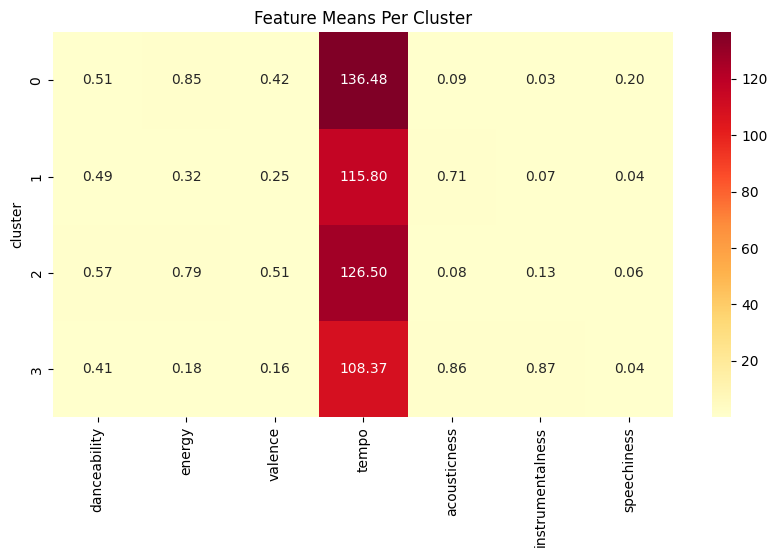

In [11]:
cluster_profile = df.groupby("cluster")[features].mean()
print(cluster_profile)

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profile, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Feature Means Per Cluster")
plt.savefig("../plots/feature_means_heatmap.png", dpi=150)
plt.show()

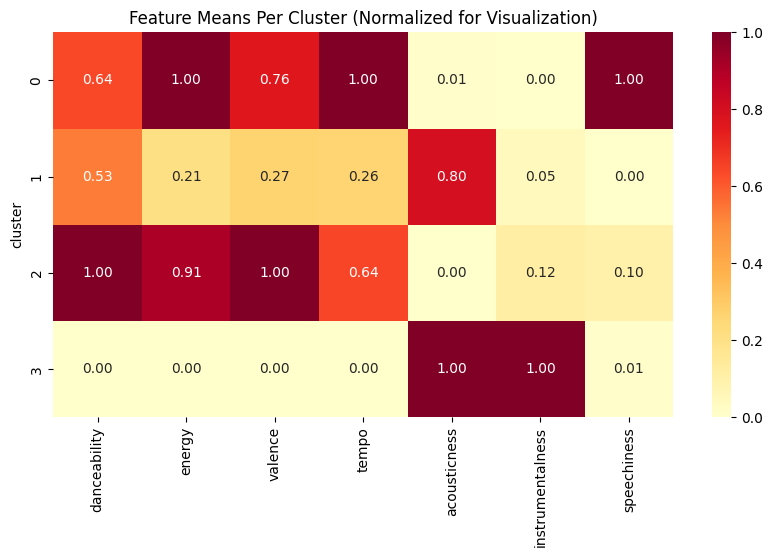

In [12]:
#normalizing cluster profile for the visualization since above
#makes it look like tempo is really important compared to other features
#and scaling is off
from sklearn.preprocessing import MinMaxScaler

viz_scaler = MinMaxScaler()
cluster_profile_normalized = pd.DataFrame(
    viz_scaler.fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profile_normalized, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Feature Means Per Cluster (Normalized for Visualization)")
plt.savefig("../plots/feature_means_heatmap_normalized.png", dpi=150)
plt.show()


mood     Calm  Energetic  Happy  Sad
cluster                             
0           0         19      9    3
1           1          1      5  123
2           3        134    126   43
3         191          0      0   28


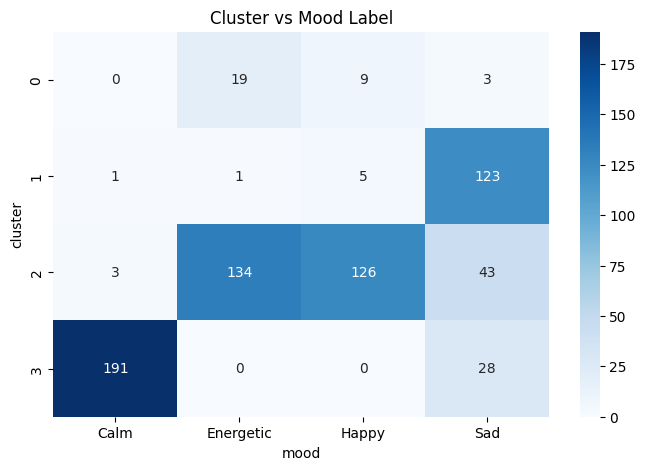

In [13]:
comparison = pd.crosstab(df["cluster"], df["mood"])
print(comparison)

plt.figure(figsize=(8, 5))
sns.heatmap(comparison, annot=True, fmt="d", cmap="Blues")
plt.title("Cluster vs Mood Label")
plt.savefig("../plots/mood_heatmap.png", dpi=150)
plt.show()

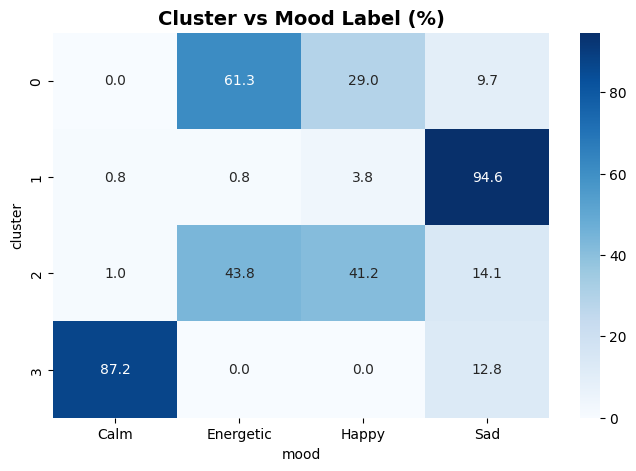

In [22]:
comparison_pct = pd.crosstab(
    df["cluster"],
    df["mood"],
    normalize="index"
) * 100

plt.figure(figsize=(8, 5))
sns.heatmap(comparison_pct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Cluster vs Mood Label (%)", fontsize=14, fontweight='bold')
plt.savefig("../plots/mood_heatmap_pct.png", dpi=150, bbox_inches='tight')
plt.show()

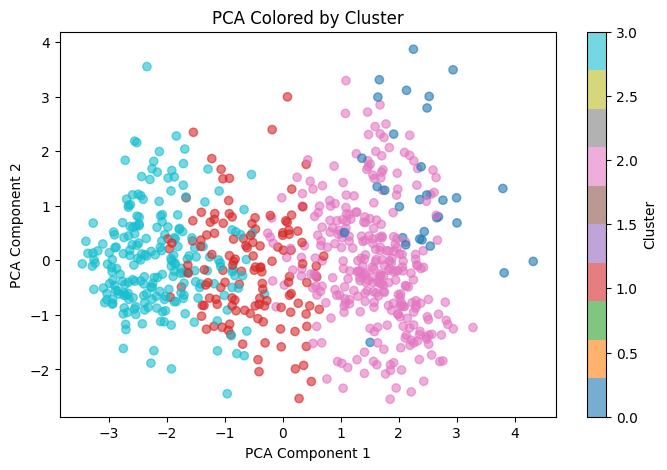

In [14]:
#PCA colored by cluster
pca = PCA(n_components=2) #creating a PCA object to compress data to 2 components
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
#X-axis and y-axis
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df["cluster"], cmap="tab10", alpha=0.6)
plt.colorbar(scatter, label="Cluster")
plt.title("PCA Colored by Cluster")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.savefig("../plots/pca_cluster.png", dpi=150)
plt.show()

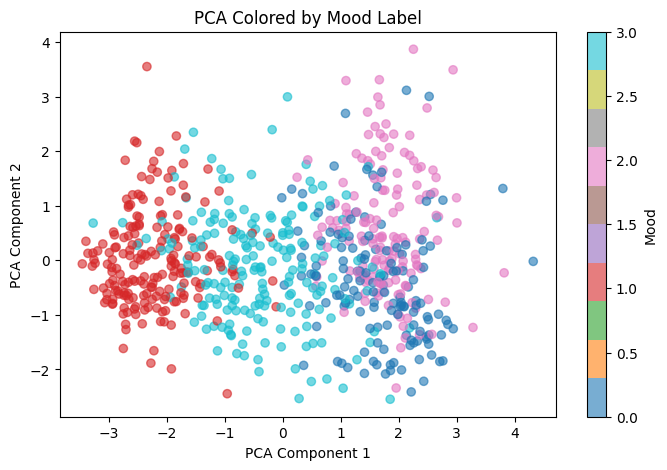

In [15]:
#PCA colored by mood
mood_map = {"Happy": 0, "Calm": 1, "Energetic": 2, "Sad": 3}
df["mood_code"] = df["mood"].map(mood_map)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df["mood_code"], cmap="tab10", alpha=0.6)
plt.colorbar(scatter, label="Mood")
plt.title("PCA Colored by Mood Label")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.savefig("../plots/pca_mood.png", dpi=150)
plt.show()


In [16]:
#To compare K-Means clustering with Agglomerative Clustering to see which one works best for this analysis.
from sklearn.cluster import AgglomerativeClustering

agg_method = AgglomerativeClustering(n_clusters=4)
agg_labels = agg_method.fit_predict(X_scaled)

agg_score = silhouette_score(X_scaled, agg_labels)
print(f"K-Means Silhouette Score:       0.2631") #got this number from a few cells above
print(f"Agglomerative Silhouette Score: {agg_score:.4f}")

if 0.2631 > agg_score:
    print("\nK-Means performed better for this dataset")
else:
    print("\nAgglomerative performed better for this dataset")

K-Means Silhouette Score:       0.2631
Agglomerative Silhouette Score: 0.2467

K-Means performed better for this dataset


In [19]:
#recommendation system
from sklearn.metrics.pairwise import cosine_similarity
def recommend_songs(song_title, df, X_scaled, n=5):
    try:
        idx = df[df["name"] == song_title].index[0]
        song_cluster = df.loc[idx, "cluster"]
        
        cluster_mask = df["cluster"] == song_cluster
        cluster_indices = df[cluster_mask].index
        
        similarities = cosine_similarity(
            [X_scaled[idx]], X_scaled[cluster_mask]
        )[0]
        
        top_n = similarities.argsort()[::-1][1:n+1]
        return df.iloc[cluster_indices[top_n]][["name", "artist", "mood", "cluster"]]
    except IndexError:
        return "Song not found"

# Test across all four clusters
for cluster_id in range(4):
    sample = df[df["cluster"] == cluster_id]["name"].iloc[0]
    print(f"\nCluster {cluster_id} recommendations for: {sample}")
    print(recommend_songs(sample, df, X_scaled))



Cluster 0 recommendations for: A Place for My Head
                                          name            artist       mood  \
661                  You Can't Rely on My Love           Mordkey      Happy   
581                                      Toxic  A Static Lullaby  Energetic   
523         Sun In Our Eyes - Don Diablo Remix                MØ      Happy   
614  Waiting For Tomorrow (feat. Mike Shinoda)     Martin Garrix  Energetic   
236                            Highway to Hell             AC/DC      Happy   

     cluster  
661        0  
581        0  
523        0  
614        0  
236        0  

Cluster 1 recommendations for: 9 Crimes
                         name          artist mood  cluster
324             Long Way Down       Tom Odell  Sad        1
437  Quiet, The Winter Harbor      Mazzy Star  Sad        1
284                        K.    Rosie Carney  Sad        1
98                  Cold Arms  Mumford & Sons  Sad        1
277                   Jealous        Labri